In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
 
# transformer_lens ships everything we need
from transformer_lens import utils
from transformer_lens.model_bridge import TransformerBridge
from transformer_lens.hook_points import HookPoint
 
os.makedirs("ioi_outputs", exist_ok=True)
 
# Use GPU 0 by default (you have 4 H200s — plenty of headroom)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

/tmp/ipykernel_476469/1353804209.py:8: DeprecationWarning: The 'utils' module has been deprecated. Please use 'transformer_lens.utilities' instead. Importing from utils.py will be removed in TransformerLens 4.0.
  from transformer_lens import utils


Using device: cuda


In [2]:
# ─────────────────────────────────────────────
# 1.  LOAD GPT-2 SMALL
# ─────────────────────────────────────────────
# GPT-2 Small: 12 layers, 12 heads per layer, d_model=768
# TransformerLens downloads weights from HuggingFace automatically.

model = TransformerBridge.boot_transformers("gpt2")
model.eval()
 
print(f"\nModel loaded.")
print(f"  Layers : {model.cfg.n_layers}")   # 12
print(f"  Heads  : {model.cfg.n_heads}")    # 12
print(f"  d_model: {model.cfg.d_model}")    # 768
print(f"  d_head : {model.cfg.d_head}")     # 64


Model loaded.
  Layers : 12
  Heads  : 12
  d_model: 768
  d_head : 64


 ─────────────────────────────────────────────
## 2.  DEFINE THE IOI SENTENCE
 ─────────────────────────────────────────────
This is the canonical sentence from Wang et al.

Position labels (0-indexed):

    0:"When"  1:"Mary"  2:"and"  3:"John"  4:"went"

    5:"to"    6:"the"   7:"store"  8:","

    9:"John"  10:"gave"  11:"a"  12:"drink"  13:"to"

### Key positions:
   IO  = 1   (Mary — the Indirect Object)

   S1  = 3   (first John — Subject occurrence 1)

   S1+1= 4   (went — token right after S1, used by PTH)

   S2  = 9   (second John — Subject occurrence 2)

   END = 13  (to — where the prediction is made)

In [3]:
CLEAN_PROMPT = "When Mary and John went to the store, John gave a drink to"
CORRUPT_PROMPT = "When Lisa and John went to the store, John gave a drink to"
# In the corrupted prompt, Mary → Lisa. The circuit should now predict "Lisa".
 
tokens_clean   = model.to_tokens(CLEAN_PROMPT)    # shape [1, seq_len]
tokens_corrupt = model.to_tokens(CORRUPT_PROMPT)
 
# Decode to verify positions
token_strs = model.to_str_tokens(CLEAN_PROMPT)
print("\nToken positions (clean prompt):")
for i, t in enumerate(token_strs):
    print(f"  posn {i:2d}: '{t}'")
 
# Named positions — we'll use these everywhere
IO_POS  = token_strs.index(" Mary")   # should be 1
S1_POS  = token_strs.index(" John")   # first occurrence → 3
S2_POS  = len(token_strs) - 1 - token_strs[::-1].index(" John")  # last John → 9
END_POS = len(token_strs) - 1         # last token → 13
S1_PLUS_1 = S1_POS + 1                # 4 ("went")
 
print(f"\nKey positions: IO={IO_POS}, S1={S1_POS}, S1+1={S1_PLUS_1}, "
      f"S2={S2_POS}, END={END_POS}")


Token positions (clean prompt):
  posn  0: '<|endoftext|>'
  posn  1: 'When'
  posn  2: ' Mary'
  posn  3: ' and'
  posn  4: ' John'
  posn  5: ' went'
  posn  6: ' to'
  posn  7: ' the'
  posn  8: ' store'
  posn  9: ','
  posn 10: ' John'
  posn 11: ' gave'
  posn 12: ' a'
  posn 13: ' drink'
  posn 14: ' to'

Key positions: IO=2, S1=4, S1+1=5, S2=10, END=14


In [4]:
# ─────────────────────────────────────────────
# 3.  SANITY CHECK — WHAT DOES THE MODEL PREDICT?
# ─────────────────────────────────────────────
with torch.no_grad():
    logits_clean,   cache_clean   = model.run_with_cache(tokens_clean)
    logits_corrupt, cache_corrupt = model.run_with_cache(tokens_corrupt)
 
# Logits at END position (last token predicts next)
end_logits_clean   = logits_clean[0, END_POS, :]    # [vocab]
end_logits_corrupt = logits_corrupt[0, END_POS, :]
 
# Top-5 predictions for clean prompt
top5_clean = end_logits_clean.topk(5)
print("\nTop-5 predictions (clean prompt — expect 'Mary' near top):")
for rank, (val, idx) in enumerate(zip(top5_clean.values, top5_clean.indices)):
    print(f"  {rank+1}. '{model.to_string(idx)}' (logit={val:.2f})")
 
top5_corrupt = end_logits_corrupt.topk(5)
print("\nTop-5 predictions (corrupt prompt — expect 'Lisa' near top):")
for rank, (val, idx) in enumerate(zip(top5_corrupt.values, top5_corrupt.indices)):
    print(f"  {rank+1}. '{model.to_string(idx)}' (logit={val:.2f})")
 
# The logit difference we'll use throughout as our metric
# A positive value means the model prefers the IO name over the subject name.
mary_token = model.to_single_token(" Mary")
john_token = model.to_single_token(" John")
lisa_token  = model.to_single_token(" Lisa")
 
logit_diff_clean = (end_logits_clean[mary_token] -
                    end_logits_clean[john_token]).item()
print(f"\nClean logit diff (Mary - John) at END: {logit_diff_clean:.3f}")
# Expect positive — model should prefer Mary


Top-5 predictions (clean prompt — expect 'Mary' near top):
  1. ' Mary' (logit=-74.75)
  2. ' them' (logit=-76.42)
  3. ' the' (logit=-77.41)
  4. ' John' (logit=-78.11)
  5. ' her' (logit=-78.62)

Top-5 predictions (corrupt prompt — expect 'Lisa' near top):
  1. ' Lisa' (logit=-75.25)
  2. ' them' (logit=-77.16)
  3. ' the' (logit=-77.64)
  4. ' her' (logit=-78.07)
  5. ' their' (logit=-78.83)

Clean logit diff (Mary - John) at END: 3.362


## 4.  HELPER: VISUALISE AN ATTENTION PATTERN

In [5]:
def plot_attention(attn_pattern, layer, head, token_strs, title_suffix="",
                   save_path=None):
    """
    Plot a single head's attention pattern as a heatmap.
    attn_pattern: [seq, seq] tensor — attn_pattern[dest, src] = weight.
    """
    seq = len(token_strs)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(attn_pattern[:seq, :seq].cpu().float().numpy(),
                   cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(seq))
    ax.set_yticks(range(seq))
    ax.set_xticklabels([f"{i}:{t}" for i, t in enumerate(token_strs)],
                       rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels([f"{i}:{t}" for i, t in enumerate(token_strs)],
                       fontsize=8)
    ax.set_xlabel("Source (attending FROM here is columns → attend TO rows)")
    ax.set_ylabel("Destination (this token is asking the query)")
    ax.set_title(f"Layer {layer}, Head {head}  {title_suffix}")
    plt.colorbar(im, ax=ax, label="Attention weight")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
        print(f"  Saved: {save_path}")
    plt.show()
    plt.close()


SECTION 5: Duplicate Token Heads (DTH)
Checking which heads at S2 attend strongly to S1 (both 'John')...

Top 10 heads by attn weight at [S2→S1] (expect 0.1, 3.0 near top):
  Head         attn[S2,S1]
  ----------  ------------
  L 3.H 0           0.7107 ◄ DTH (paper)
  L 1.H11           0.6644
  L 0.H 5           0.5515
  L 0.H 1           0.5163 ◄ DTH (paper)
  L 0.H10           0.2221
  L 1.H 5           0.1494
  L 0.H 8           0.1475
  L 0.H 6           0.1295
  L 0.H 0           0.0966
  L 1.H10           0.0903

L0.H1 attention at S2 position:
  src= 0 '<|endoftext|>' : 0.0002  
  src= 1 'When    ' : 0.0045  
  src= 2 ' Mary   ' : 0.0019  
  src= 3 ' and    ' : 0.0004  
  src= 4 ' John   ' : 0.5163  ████████████████████
  src= 5 ' went   ' : 0.0009  
  src= 6 ' to     ' : 0.0002  
  src= 7 ' the    ' : 0.0008  
  src= 8 ' store  ' : 0.0000  
  src= 9 ',       ' : 0.0000  
  src=10 ' John   ' : 0.4747  ██████████████████
  src=11 ' gave   ' : 0.0000  
  src=12 ' a      ' : 0.00

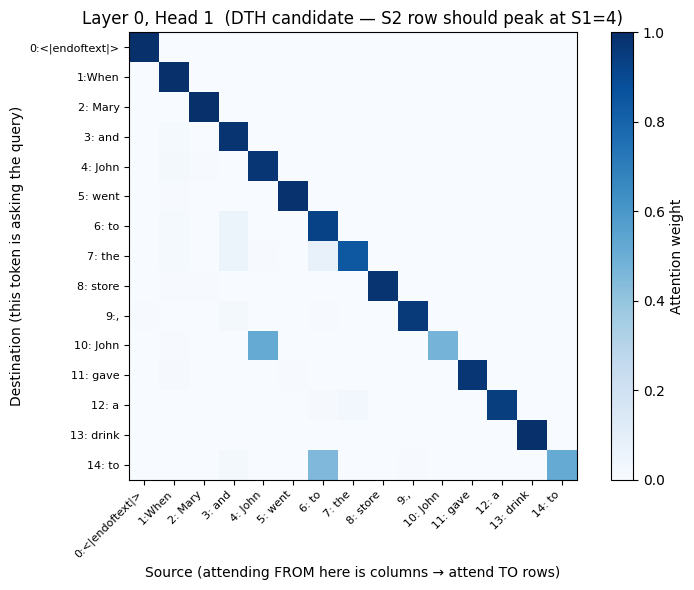


L3.H0 attention at S2 position:
  src= 0 '<|endoftext|>' : 0.1927  ███████
  src= 1 'When    ' : 0.0024  
  src= 2 ' Mary   ' : 0.0018  
  src= 3 ' and    ' : 0.0055  
  src= 4 ' John   ' : 0.7107  ████████████████████████████
  src= 5 ' went   ' : 0.0017  
  src= 6 ' to     ' : 0.0012  
  src= 7 ' the    ' : 0.0087  
  src= 8 ' store  ' : 0.0000  
  src= 9 ',       ' : 0.0028  
  src=10 ' John   ' : 0.0725  ██
  src=11 ' gave   ' : 0.0000  
  src=12 ' a      ' : 0.0000  
  src=13 ' drink  ' : 0.0000  
  src=14 ' to     ' : 0.0000  
  Saved: ioi_outputs/dth_L3H0.png


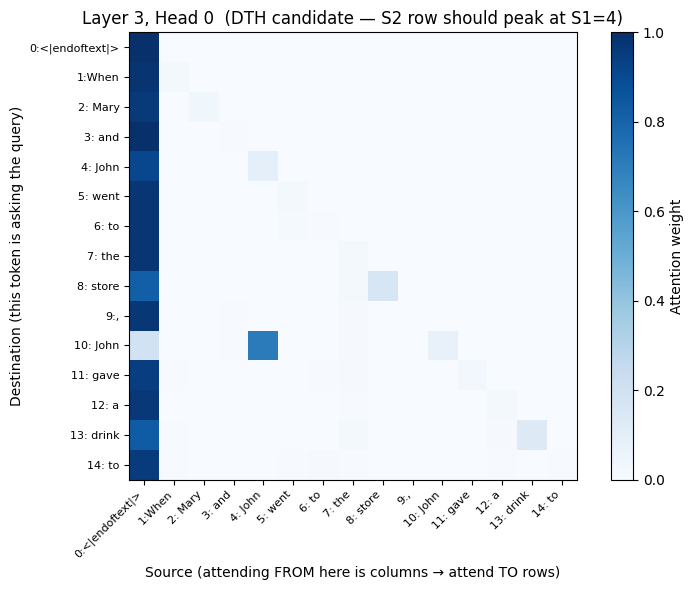

In [6]:
# ─────────────────────────────────────────────
# 5.  VALIDATE DUPLICATE TOKEN HEADS (DTH)
# ─────────────────────────────────────────────
# DTH Signature:
#   A head is a DTH if, when sitting at S2 (the second "John"),
#   it attends back strongly to S1 (the first "John").
#   The Q/K matching is essentially: "find a token identical to me."
#
# Expected DTH heads: 0.1, 3.0  (layer.head notation)
#
# How to verify:
#   1. Look at the attention pattern of the candidate head at position S2.
#      It should attend strongly to S1.
#   2. Quantify: attn[S2, S1] should be high (>> attn[S2, other_positions]).
#   3. Check it does NOT do this for non-repeated tokens (e.g., Mary).
 
print("\n" + "="*60)
print("SECTION 5: Duplicate Token Heads (DTH)")
print("="*60)
print("Checking which heads at S2 attend strongly to S1 (both 'John')...")
 
DTH_CANDIDATES = [(0, 1), (3, 0)]   # (layer, head) from the paper
# We'll also scan layers 0–4 to see if we find more.
 
# TransformerLens cache key for attention patterns:
# cache["pattern", layer]  → shape [batch, heads, seq, seq]
#   [batch, head, dest, src]  — dest attends to src
 
dth_scores = {}   # (layer, head) → attn weight at [S2, S1]
 
for layer in range(5):  # scan layers 0-4
    pattern = cache_clean[f"blocks.{layer}.attn.hook_pattern"]  # [1, 12, seq, seq]
    for head in range(model.cfg.n_heads):
        score = pattern[0, head, S2_POS, S1_POS].item()
        dth_scores[(layer, head)] = score
 
# Sort and print top 10
sorted_dth = sorted(dth_scores.items(), key=lambda x: -x[1])
print(f"\nTop 10 heads by attn weight at [S2→S1] (expect 0.1, 3.0 near top):")
print(f"  {'Head':10s}  {'attn[S2,S1]':>12s}")
print(f"  {'-'*10}  {'-'*12}")
for (layer, head), score in sorted_dth[:10]:
    marker = " ◄ DTH (paper)" if (layer, head) in DTH_CANDIDATES else ""
    print(f"  L{layer:2d}.H{head:2d}     {score:>12.4f}{marker}")
 
# Plot attention patterns for the paper's DTH heads
for layer, head in DTH_CANDIDATES:
    pattern = cache_clean[f"blocks.{layer}.attn.hook_pattern"][0, head]    # [seq, seq]
    print(f"\nL{layer}.H{head} attention at S2 position:")
    for src_pos in range(len(token_strs)):
        bar = "█" * int(pattern[S2_POS, src_pos].item() * 40)
        print(f"  src={src_pos:2d} '{token_strs[src_pos]:8s}' : "
              f"{pattern[S2_POS, src_pos].item():.4f}  {bar}")
    plot_attention(
        pattern, layer, head, token_strs,
        title_suffix=f"(DTH candidate — S2 row should peak at S1={S1_POS})",
        save_path=f"ioi_outputs/dth_L{layer}H{head}.png"
    )


SECTION 6: Previous Token Heads (PTH)
Checking which heads attend from each token to the previous token...

Top 10 heads by avg attn[t, t-1] (expect 2.2, 4.11 near top):
  Head         avg_prev_attn
  ----------  --------------
  L 4.H11             1.0000 ◄ PTH (paper)
  L 2.H 2             0.5684 ◄ PTH (paper)
  L 3.H 2             0.4356
  L 3.H 7             0.4120
  L 2.H 9             0.3954
  L 2.H 8             0.3411
  L 2.H 5             0.3402
  L 1.H 0             0.3300
  L 2.H 4             0.3149
  L 0.H 7             0.3112

L2.H2 attention at S1+1=' went' (posn 5):
  src= 0 '<|endoftext|>' : 0.1159  ████
  src= 1 'When    ' : 0.0473  █
  src= 2 ' Mary   ' : 0.0235  
  src= 3 ' and    ' : 0.6255  █████████████████████████
  src= 4 ' John   ' : 0.1452  █████
  src= 5 ' went   ' : 0.0425  █
  src= 6 ' to     ' : 0.0000  
  src= 7 ' the    ' : 0.0000  
  src= 8 ' store  ' : 0.0000  
  src= 9 ',       ' : 0.0000  
  src=10 ' John   ' : 0.0000  
  src=11 ' gave   ' : 0.0000

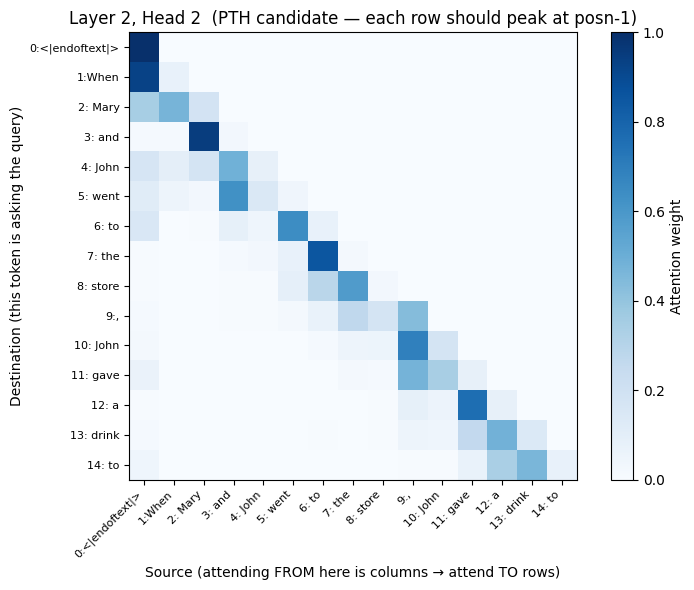


L4.H11 attention at S1+1=' went' (posn 5):
  src= 0 '<|endoftext|>' : 0.0000  
  src= 1 'When    ' : 0.0000  
  src= 2 ' Mary   ' : 0.0000  
  src= 3 ' and    ' : 0.0000  
  src= 4 ' John   ' : 1.0000  ███████████████████████████████████████
  src= 5 ' went   ' : 0.0000  
  src= 6 ' to     ' : 0.0000  
  src= 7 ' the    ' : 0.0000  
  src= 8 ' store  ' : 0.0000  
  src= 9 ',       ' : 0.0000  
  src=10 ' John   ' : 0.0000  
  src=11 ' gave   ' : 0.0000  
  src=12 ' a      ' : 0.0000  
  src=13 ' drink  ' : 0.0000  
  src=14 ' to     ' : 0.0000  
  Saved: ioi_outputs/pth_L4H11.png


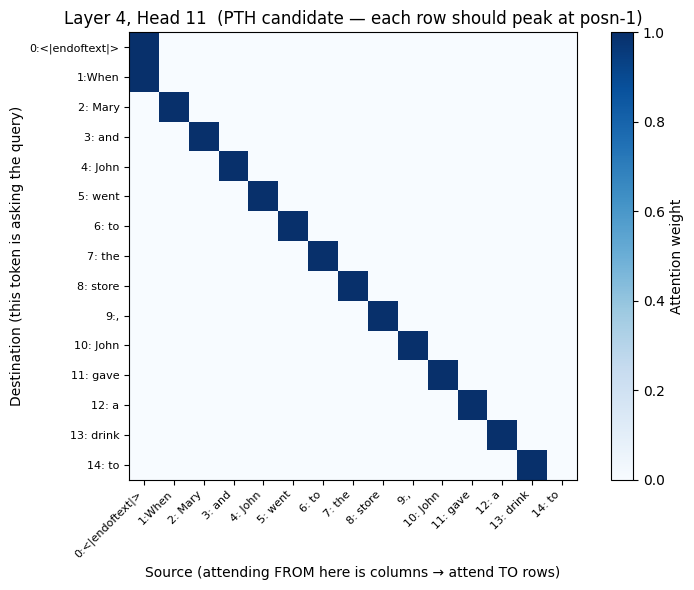

In [9]:
# ─────────────────────────────────────────────
# 6.  VALIDATE PREVIOUS TOKEN HEADS (PTH)
# ─────────────────────────────────────────────
# PTH Signature:
#   A head at position S1+1 ("went") attends to the PREVIOUS token S1 ("John").
#   So attn[S1+1, S1] should be high.
#   More generally, PTH have high attn[t, t-1] across ALL positions —
#   they implement a generic "look one step back" operation.
#
# Expected PTH heads: 2.2, 4.11
 
print("\n" + "="*60)
print("SECTION 6: Previous Token Heads (PTH)")
print("="*60)
print("Checking which heads attend from each token to the previous token...")
 
PTH_CANDIDATES = [(2, 2), (4, 11)]
 
# PTH score: average attn[t, t-1] across all positions t > 0
pth_scores = {}
for layer in range(6):
    pattern = cache_clean[f"blocks.{layer}.attn.hook_pattern"][0]  # [heads, seq, seq]
    for head in range(model.cfg.n_heads):
        # Average over all (t, t-1) pairs
        prev_attn = [pattern[head, t, t-1].item()
                     for t in range(1, len(token_strs))]
        pth_scores[(layer, head)] = np.mean(prev_attn)
 
sorted_pth = sorted(pth_scores.items(), key=lambda x: -x[1])
print(f"\nTop 10 heads by avg attn[t, t-1] (expect 2.2, 4.11 near top):")
print(f"  {'Head':10s}  {'avg_prev_attn':>14s}")
print(f"  {'-'*10}  {'-'*14}")
for (layer, head), score in sorted_pth[:10]:
    marker = " ◄ PTH (paper)" if (layer, head) in PTH_CANDIDATES else ""
    print(f"  L{layer:2d}.H{head:2d}     {score:>14.4f}{marker}")
 
# Show the full attention row for S1+1 ("went") for paper PTH heads
for layer, head in PTH_CANDIDATES:
    pattern = cache_clean[f"blocks.{layer}.attn.hook_pattern"][0, head]
    print(f"\nL{layer}.H{head} attention at S1+1='{token_strs[S1_PLUS_1]}' (posn {S1_PLUS_1}):")
    for src_pos in range(len(token_strs)):
        bar = "█" * int(pattern[S1_PLUS_1, src_pos].item() * 40)
        print(f"  src={src_pos:2d} '{token_strs[src_pos]:8s}' : "
              f"{pattern[S1_PLUS_1, src_pos].item():.4f}  {bar}")
    plot_attention(
        pattern, layer, head, token_strs,
        title_suffix=f"(PTH candidate — each row should peak at posn-1)",
        save_path=f"ioi_outputs/pth_L{layer}H{head}.png"
    )


SECTION 7: Induction Heads (IH)
Checking which heads at S2 attend to S1+1=posn 5 (' went')...

Top 10 heads by attn weight at [S2→S1+1] (expect 5.5, 6.9 near top):
  Head         attn[S2,S1+1]
  ----------  --------------
  L 5.H 5             0.9174 ◄ IH (paper)
  L 5.H 8             0.6882 ◄ IH (paper)
  L 6.H 3             0.3014
  L 5.H 0             0.2717
  L 6.H 6             0.1503
  L 7.H11             0.1352
  L 5.H 9             0.1126
  L 5.H 4             0.0961
  L 8.H 6             0.0949
  L 6.H 4             0.0835

L5.H5 attention at S2=posn 10:
  src= 0 '<|endoftext|>' : 0.0708  ██
  src= 1 'When    ' : 0.0004  
  src= 2 ' Mary   ' : 0.0004  
  src= 3 ' and    ' : 0.0001  
  src= 4 ' John   ' : 0.0015  
  src= 5 ' went   ' : 0.9174  ████████████████████████████████████
  src= 6 ' to     ' : 0.0004  
  src= 7 ' the    ' : 0.0010  
  src= 8 ' store  ' : 0.0078  
  src= 9 ',       ' : 0.0000  
  src=10 ' John   ' : 0.0003  
  src=11 ' gave   ' : 0.0000  
  src=12 ' a  

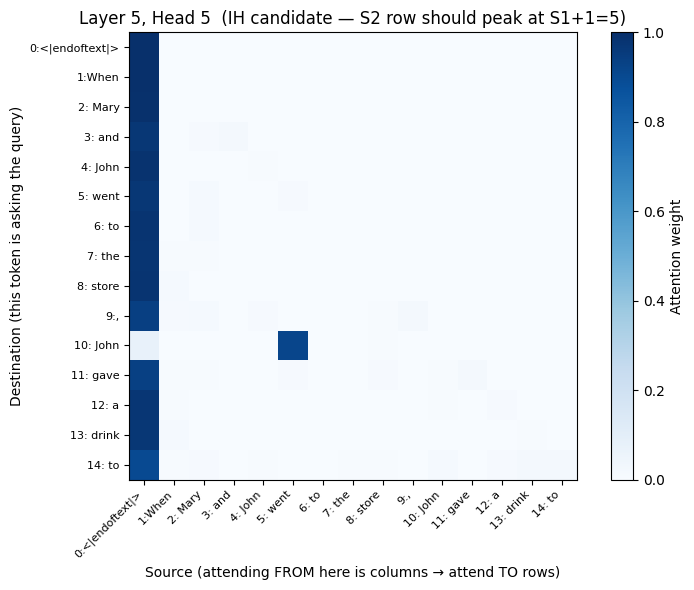


L5.H8 attention at S2=posn 10:
  src= 0 '<|endoftext|>' : 0.2483  █████████
  src= 1 'When    ' : 0.0013  
  src= 2 ' Mary   ' : 0.0015  
  src= 3 ' and    ' : 0.0045  
  src= 4 ' John   ' : 0.0021  
  src= 5 ' went   ' : 0.6882  ███████████████████████████
  src= 6 ' to     ' : 0.0225  
  src= 7 ' the    ' : 0.0191  
  src= 8 ' store  ' : 0.0056  
  src= 9 ',       ' : 0.0012  
  src=10 ' John   ' : 0.0056  
  src=11 ' gave   ' : 0.0000  
  src=12 ' a      ' : 0.0000  
  src=13 ' drink  ' : 0.0000  
  src=14 ' to     ' : 0.0000  
  Saved: ioi_outputs/ih_L5H8.png


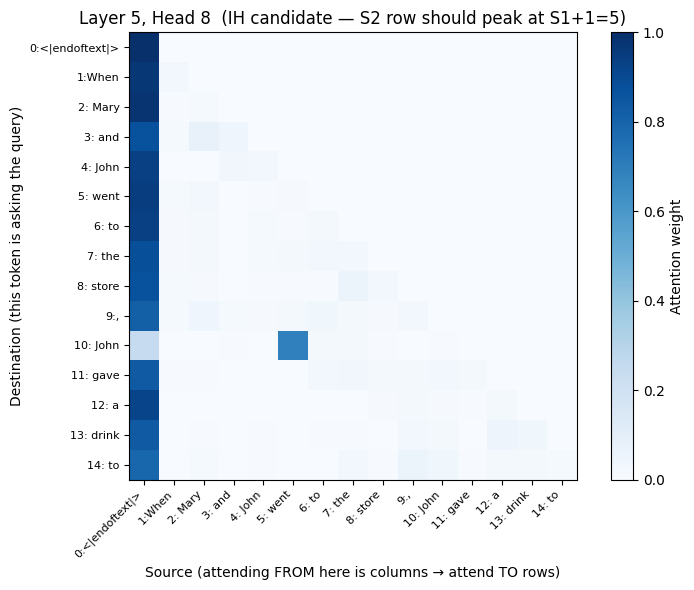

In [12]:
# ─────────────────────────────────────────────
# 7.  VALIDATE INDUCTION HEADS (IH)
# ─────────────────────────────────────────────
# IH Signature:
#   An induction head at S2 ("John", posn 9) attends to S1+1 ("went", posn 4).
#   Why? Because induction heads look for the pattern:
#       [A][B] ... [A] → predict [B]
#   Here: [John][went] appeared earlier, so at [John S2] the IH predicts "went".
#   But crucially, the IH also carries information about WHERE the repeated
#   token appeared, which helps DTH and SIH downstream.
#
#   Formally: attn[S2, S1+1] should be high.
#
# Expected IH heads: 5.5, 6.9 (also 5.8, 5.9 in some analyses)
 
print("\n" + "="*60)
print("SECTION 7: Induction Heads (IH)")
print("="*60)
print(f"Checking which heads at S2 attend to S1+1=posn {S1_PLUS_1} ('{token_strs[S1_PLUS_1]}')...")
 
IH_CANDIDATES = [(5, 5), (5,8)]
 
ih_scores = {}
for layer in range(4, 10):  # IH typically in layers 4-7
    pattern = cache_clean["pattern", layer][0]
    for head in range(model.cfg.n_heads):
        score = pattern[head, S2_POS, S1_PLUS_1].item()
        ih_scores[(layer, head)] = score
 
sorted_ih = sorted(ih_scores.items(), key=lambda x: -x[1])
print(f"\nTop 10 heads by attn weight at [S2→S1+1] (expect 5.5, 6.9 near top):")
print(f"  {'Head':10s}  {'attn[S2,S1+1]':>14s}")
print(f"  {'-'*10}  {'-'*14}")
for (layer, head), score in sorted_ih[:10]:
    marker = " ◄ IH (paper)" if (layer, head) in IH_CANDIDATES else ""
    print(f"  L{layer:2d}.H{head:2d}     {score:>14.4f}{marker}")
 
for layer, head in IH_CANDIDATES:
    pattern = cache_clean["pattern", layer][0, head]
    print(f"\nL{layer}.H{head} attention at S2=posn {S2_POS}:")
    for src_pos in range(len(token_strs)):
        bar = "█" * int(pattern[S2_POS, src_pos].item() * 40)
        print(f"  src={src_pos:2d} '{token_strs[src_pos]:8s}' : "
              f"{pattern[S2_POS, src_pos].item():.4f}  {bar}")
    plot_attention(
        pattern, layer, head, token_strs,
        title_suffix=f"(IH candidate — S2 row should peak at S1+1={S1_PLUS_1})",
        save_path=f"ioi_outputs/ih_L{layer}H{head}.png"
    )

In [14]:
def plot_attention(attn_pattern, layer, head, token_strs,
                  highlight_dest=None, highlight_src=None,
                  title_suffix="", save_path=None):
    """
    Plot attention heatmap. Optionally highlight a specific (dest, src) cell
    with a red border to show the expected peak.
    """
    seq = len(token_strs)
    fig, ax = plt.subplots(figsize=(9, 7))
    data = attn_pattern[:seq, :seq].cpu().float().numpy()
    im   = ax.imshow(data, cmap="Blues", vmin=0, vmax=1)
 
    ax.set_xticks(range(seq))
    ax.set_yticks(range(seq))
    ax.set_xticklabels([f"{i}:{t}" for i, t in enumerate(token_strs)],
                       rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels([f"{i}:{t}" for i, t in enumerate(token_strs)],
                       fontsize=7)
    ax.set_xlabel("Source token (K/V — who is being attended TO)")
    ax.set_ylabel("Destination token (Q — who is asking)")
    ax.set_title(f"Layer {layer}, Head {head}  {title_suffix}", fontsize=10)
 
    # Draw a red rectangle around the expected peak cell
    if highlight_dest is not None and highlight_src is not None:
        from matplotlib.patches import Rectangle
        ax.add_patch(Rectangle(
            (highlight_src - 0.5, highlight_dest - 0.5), 1, 1,
            fill=False, edgecolor="red", linewidth=2.5,
            label=f"Expected peak [{highlight_dest},{highlight_src}]"
        ))
        ax.legend(loc="upper right", fontsize=8)
 
    plt.colorbar(im, ax=ax, label="Attention weight")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
        print(f"  Saved: {save_path}")
    plt.show()
    plt.close()



EXPERIMENT A — SIH Attention Patterns

Ranking all heads (layers 6–10) by attn[END, S2]:
  (SIH should attend from END=14 to S2=10)

  Head         attn[END,S2]
  ----------  -------------
  L 8.H 6            0.7881 ◄ SIH (paper)
  L 8.H10            0.4581 ◄ SIH (paper)
  L 7.H 9            0.4079 ◄ SIH (paper)
  L 8.H 5            0.2811
  L 6.H 0            0.2181
  L 7.H 3            0.1338 ◄ SIH (paper)
  L10.H 2            0.1085
  L 9.H 7            0.1017
  L 8.H 2            0.1014
  L10.H 6            0.0988
  L 6.H 3            0.0736
  L 6.H 1            0.0698

L7.H3 — full attention at END position (row 14):
  src= 0 '<|endoftext|>': 0.1732  ██████
  src= 1 'When      ': 0.0037  
  src= 2 ' Mary     ': 0.0060  
  src= 3 ' and      ': 0.0045  
  src= 4 ' John     ': 0.0090  
  src= 5 ' went     ': 0.0071  
  src= 6 ' to       ': 0.0050  
  src= 7 ' the      ': 0.0059  
  src= 8 ' store    ': 0.0160  
  src= 9 ',         ': 0.0268  █
  src=10 ' John     ': 0.1338  █████
 

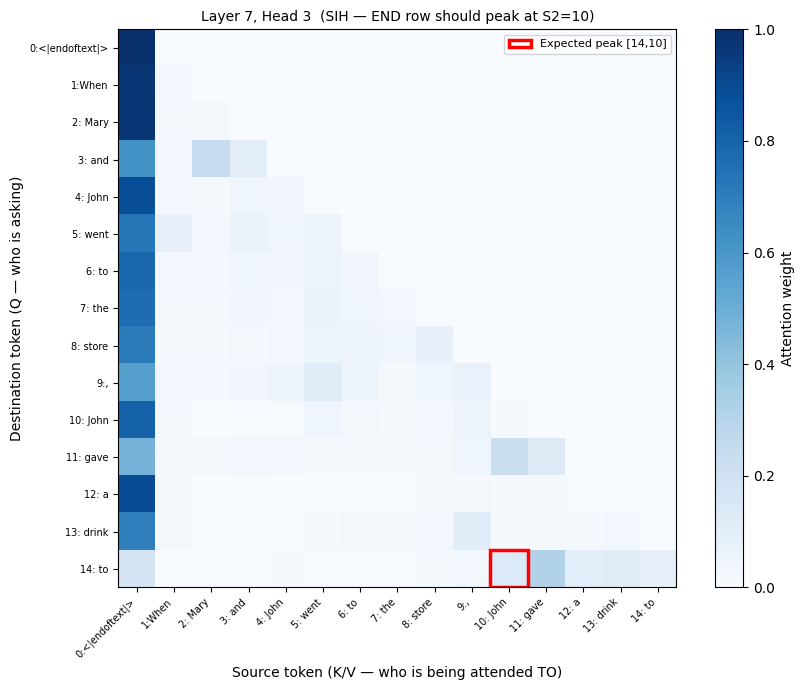


L7.H9 — full attention at END position (row 14):
  src= 0 '<|endoftext|>': 0.2307  █████████
  src= 1 'When      ': 0.0050  
  src= 2 ' Mary     ': 0.0149  
  src= 3 ' and      ': 0.0047  
  src= 4 ' John     ': 0.0260  █
  src= 5 ' went     ': 0.0121  
  src= 6 ' to       ': 0.0034  
  src= 7 ' the      ': 0.0042  
  src= 8 ' store    ': 0.0266  █
  src= 9 ',         ': 0.1230  ████
  src=10 ' John     ': 0.4079  ████████████████
  src=11 ' gave     ': 0.0576  ██
  src=12 ' a        ': 0.0198  
  src=13 ' drink    ': 0.0434  █
  src=14 ' to       ': 0.0205  
  Saved: ioi_outputs/sih_L7H9_attn.png


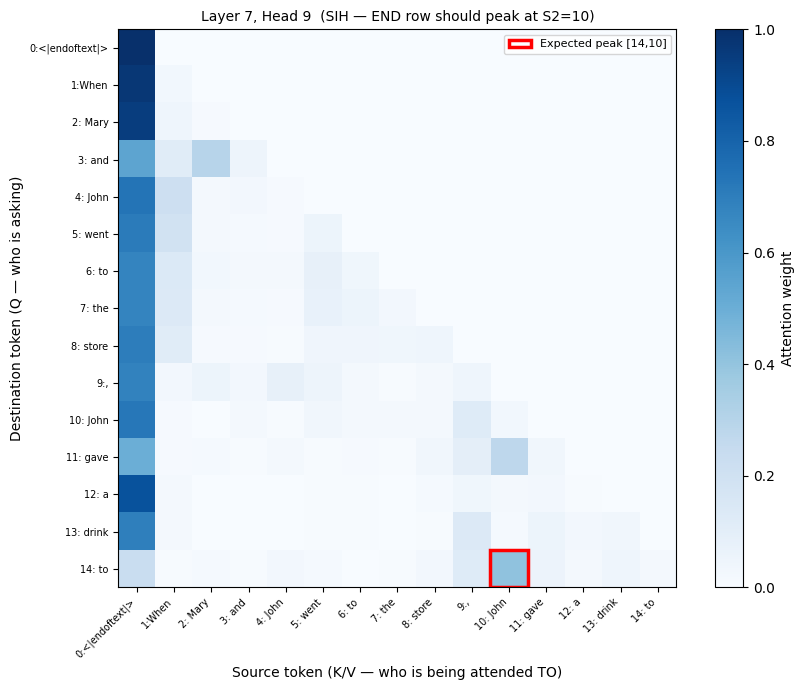


L8.H6 — full attention at END position (row 14):
  src= 0 '<|endoftext|>': 0.1314  █████
  src= 1 'When      ': 0.0003  
  src= 2 ' Mary     ': 0.0304  █
  src= 3 ' and      ': 0.0038  
  src= 4 ' John     ': 0.0324  █
  src= 5 ' went     ': 0.0003  
  src= 6 ' to       ': 0.0002  
  src= 7 ' the      ': 0.0021  
  src= 8 ' store    ': 0.0021  
  src= 9 ',         ': 0.0017  
  src=10 ' John     ': 0.7881  ███████████████████████████████
  src=11 ' gave     ': 0.0013  
  src=12 ' a        ': 0.0030  
  src=13 ' drink    ': 0.0021  
  src=14 ' to       ': 0.0008  
  Saved: ioi_outputs/sih_L8H6_attn.png


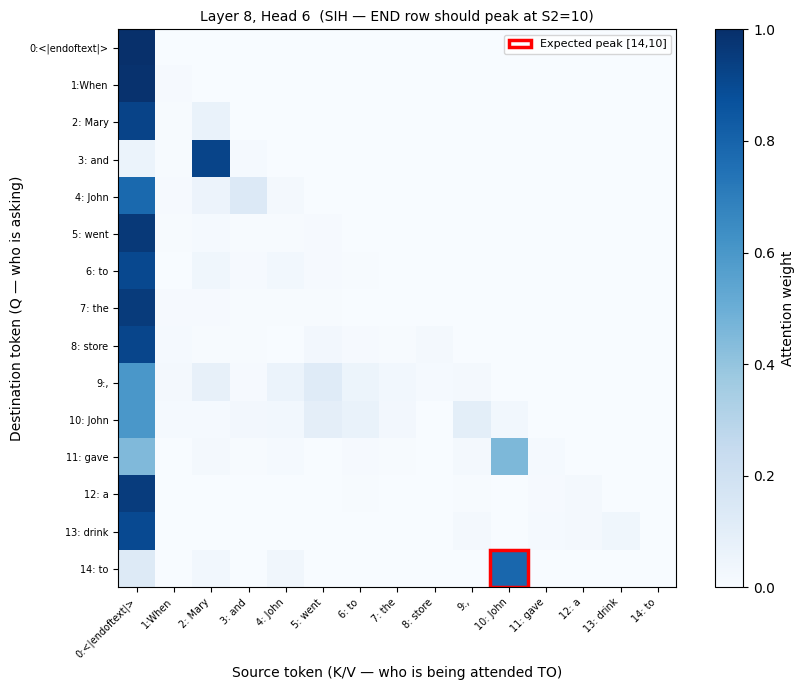


L8.H10 — full attention at END position (row 14):
  src= 0 '<|endoftext|>': 0.1925  ███████
  src= 1 'When      ': 0.0036  
  src= 2 ' Mary     ': 0.0576  ██
  src= 3 ' and      ': 0.0408  █
  src= 4 ' John     ': 0.1349  █████
  src= 5 ' went     ': 0.0100  
  src= 6 ' to       ': 0.0056  
  src= 7 ' the      ': 0.0081  
  src= 8 ' store    ': 0.0089  
  src= 9 ',         ': 0.0065  
  src=10 ' John     ': 0.4581  ██████████████████
  src=11 ' gave     ': 0.0338  █
  src=12 ' a        ': 0.0109  
  src=13 ' drink    ': 0.0115  
  src=14 ' to       ': 0.0172  
  Saved: ioi_outputs/sih_L8H10_attn.png


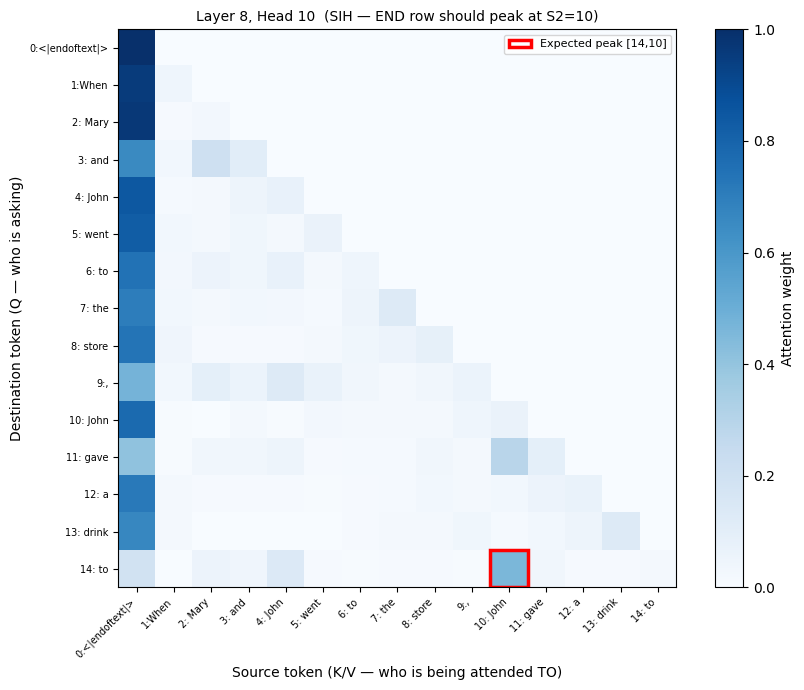

In [15]:
SIH_CANDIDATES = [(7, 3), (7, 9), (8, 6), (8, 10)]
 
 
# ═══════════════════════════════════════════════
# EXPERIMENT A — ATTENTION PATTERNS
# ═══════════════════════════════════════════════
#
# SIH signature: when sitting at END, attend strongly to S2.
#
# Why S2 specifically?
#   S2's residual stream carries the DTH/IH signal: "I am John, repeated."
#   SIH needs that K/V information to know WHICH name to suppress.
#   If SIH attended to S1 instead of S2, it would get a weaker signal
#   because S1 doesn't yet know it's repeated (DTH wrote into S2, not S1).
#
# Cache key: cache["pattern", layer]
#   Shape: [batch, n_heads, seq_len, seq_len]
#   Indexing: [batch, head, destination, source]
#   So attn[END, S2] = how much END attends to S2
 
print("\n" + "="*60)
print("EXPERIMENT A — SIH Attention Patterns")
print("="*60)
 
print("\nRanking all heads (layers 6–10) by attn[END, S2]:")
print(f"  (SIH should attend from END={END_POS} to S2={S2_POS})")
 
sih_attn_scores = {}
for layer in range(6, 11):
    pattern = cache_clean["pattern", layer]  # [1, n_heads, seq, seq]
    for head in range(model.cfg.n_heads):
        score = pattern[0, head, END_POS, S2_POS].item()
        sih_attn_scores[(layer, head)] = score
 
sorted_sih = sorted(sih_attn_scores.items(), key=lambda x: -x[1])
print(f"\n  {'Head':10s}  {'attn[END,S2]':>13s}")
print(f"  {'-'*10}  {'-'*13}")
for (l, h), score in sorted_sih[:12]:
    marker = " ◄ SIH (paper)" if (l, h) in SIH_CANDIDATES else ""
    print(f"  L{l:2d}.H{h:2d}     {score:>13.4f}{marker}")
 
# Plot attention pattern for each paper SIH head
for layer, head in SIH_CANDIDATES:
    pattern = cache_clean["pattern", layer][0, head]  # [seq, seq]
    print(f"\nL{layer}.H{head} — full attention at END position (row {END_POS}):")
    for src in range(len(token_strs)):
        bar = "█" * int(pattern[END_POS, src].item() * 40)
        print(f"  src={src:2d} '{token_strs[src]:10s}': "
              f"{pattern[END_POS, src].item():.4f}  {bar}")
 
    plot_attention(
        pattern, layer, head, token_strs,
        highlight_dest=END_POS,
        highlight_src=S2_POS,
        title_suffix=f"(SIH — END row should peak at S2={S2_POS})",
        save_path=f"ioi_outputs/sih_L{layer}H{head}_attn.png"
    )
  

EXPERIMENT A — Attention patterns: who attends to Mary?

Ranking heads (layers 9–11) by attn[END=14, IO=2]
All of NMH, BNMH, NNMH should appear near the top.

  Head         attn[END,IO]  Type
  ----------  -------------  ----------
  L10.H 7            0.8249  BNMH ◄
  L 9.H 6            0.6719  NMH  ◄
  L 9.H 9            0.6651  NMH  ◄
  L11.H10            0.5335
  L10.H 1            0.3920
  L10.H 0            0.3319  NMH  ◄
  L10.H 3            0.2150
  L10.H10            0.2149  NNMH ◄
  L 9.H 8            0.2086
  L10.H11            0.2066
  L 9.H 4            0.1733
  L 9.H 0            0.1361
  L10.H 6            0.1080  NNMH ◄
  L11.H 1            0.0992
  L11.H 5            0.0909
  L11.H 6            0.0887
  L11.H 2            0.0870
  L11.H 0            0.0723  BNMH ◄
  L 9.H 2            0.0606
  L10.H 9            0.0551
  L11.H 9            0.0540
  L 9.H 7            0.0527
  L10.H 2            0.0524
  L 9.H 5            0.0476
  L11.H11            0.0450
  L11.H 4  

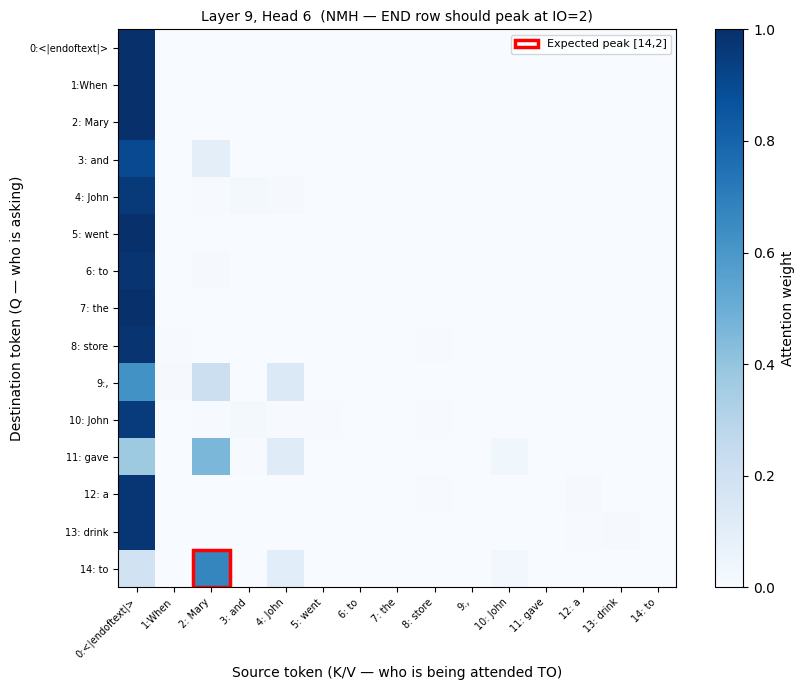


L9.H9 (NMH) — attention at END (row 14):
  src= 0 '<|endoftext|>': 0.1803  ███████
  src= 1 'When      ': 0.0158  
  src= 2 ' Mary     ': 0.6651  ██████████████████████████ ← IO (Mary)
  src= 3 ' and      ': 0.0023  
  src= 4 ' John     ': 0.0700  ██
  src= 5 ' went     ': 0.0001  
  src= 6 ' to       ': 0.0001  
  src= 7 ' the      ': 0.0010  
  src= 8 ' store    ': 0.0002  
  src= 9 ',         ': 0.0012  
  src=10 ' John     ': 0.0607  ██ ← S2 (John)
  src=11 ' gave     ': 0.0001  
  src=12 ' a        ': 0.0018  
  src=13 ' drink    ': 0.0005  
  src=14 ' to       ': 0.0006  
  Saved: ioi_outputs/nmh_L9H9_attn.png


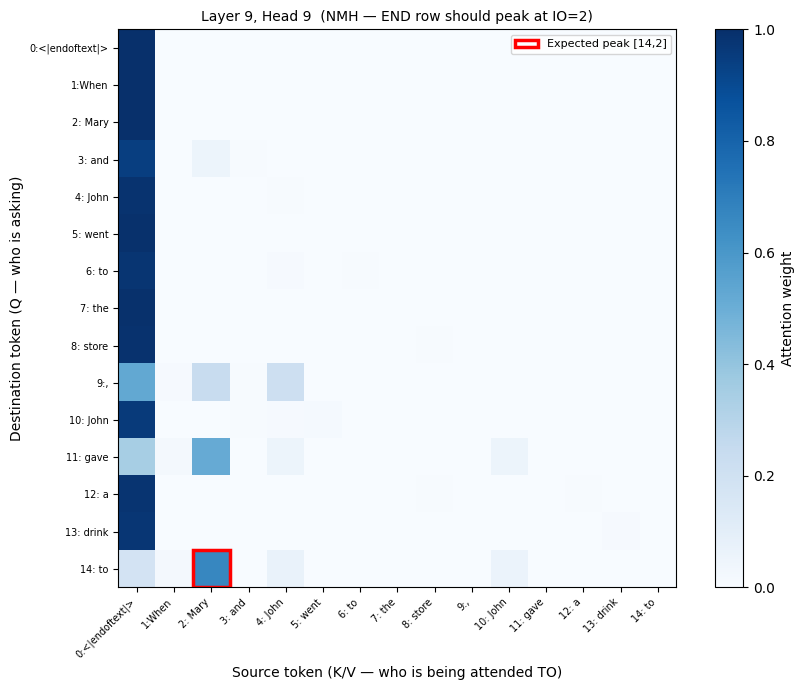


L10.H0 (NMH) — attention at END (row 14):
  src= 0 '<|endoftext|>': 0.4390  █████████████████
  src= 1 'When      ': 0.0046  
  src= 2 ' Mary     ': 0.3319  █████████████ ← IO (Mary)
  src= 3 ' and      ': 0.0053  
  src= 4 ' John     ': 0.1044  ████
  src= 5 ' went     ': 0.0022  
  src= 6 ' to       ': 0.0025  
  src= 7 ' the      ': 0.0025  
  src= 8 ' store    ': 0.0100  
  src= 9 ',         ': 0.0049  
  src=10 ' John     ': 0.0527  ██ ← S2 (John)
  src=11 ' gave     ': 0.0025  
  src=12 ' a        ': 0.0037  
  src=13 ' drink    ': 0.0211  
  src=14 ' to       ': 0.0124  
  Saved: ioi_outputs/nmh_L10H0_attn.png


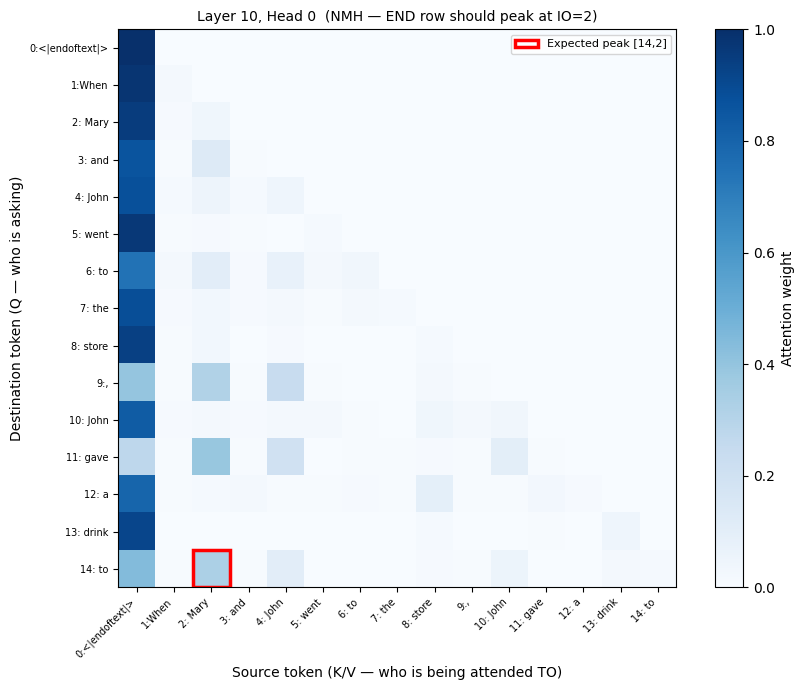


L10.H7 (BNMH) — attention at END (row 14):
  src= 0 '<|endoftext|>': 0.0334  █
  src= 1 'When      ': 0.0022  
  src= 2 ' Mary     ': 0.8249  ████████████████████████████████ ← IO (Mary)
  src= 3 ' and      ': 0.0145  
  src= 4 ' John     ': 0.0672  ██
  src= 5 ' went     ': 0.0004  
  src= 6 ' to       ': 0.0029  
  src= 7 ' the      ': 0.0032  
  src= 8 ' store    ': 0.0011  
  src= 9 ',         ': 0.0043  
  src=10 ' John     ': 0.0273  █ ← S2 (John)
  src=11 ' gave     ': 0.0020  
  src=12 ' a        ': 0.0023  
  src=13 ' drink    ': 0.0018  
  src=14 ' to       ': 0.0124  
  Saved: ioi_outputs/bnmh_L10H7_attn.png


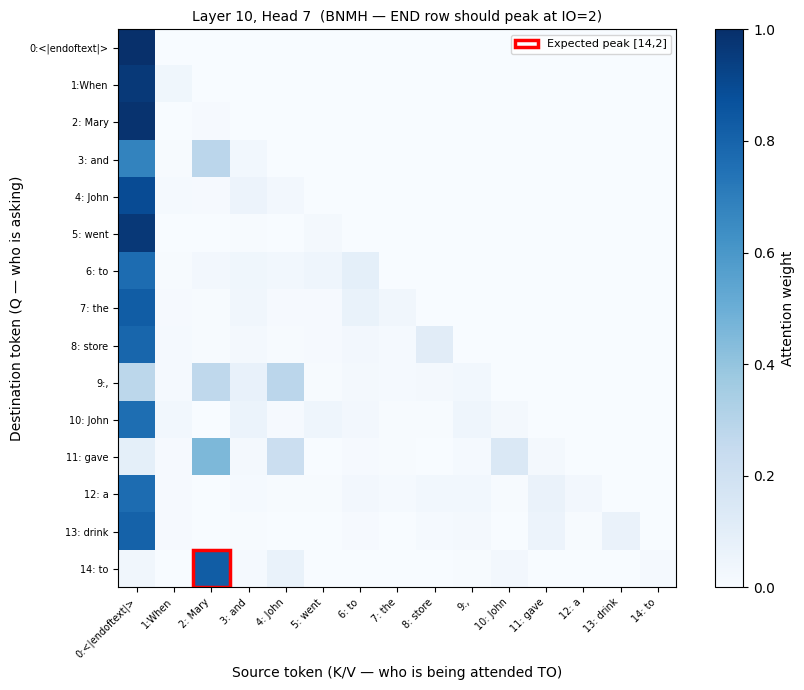


L11.H0 (BNMH) — attention at END (row 14):
  src= 0 '<|endoftext|>': 0.0715  ██
  src= 1 'When      ': 0.0863  ███
  src= 2 ' Mary     ': 0.0723  ██ ← IO (Mary)
  src= 3 ' and      ': 0.1507  ██████
  src= 4 ' John     ': 0.0853  ███
  src= 5 ' went     ': 0.0285  █
  src= 6 ' to       ': 0.0260  █
  src= 7 ' the      ': 0.0474  █
  src= 8 ' store    ': 0.0404  █
  src= 9 ',         ': 0.1014  ████
  src=10 ' John     ': 0.1390  █████ ← S2 (John)
  src=11 ' gave     ': 0.0422  █
  src=12 ' a        ': 0.0313  █
  src=13 ' drink    ': 0.0362  █
  src=14 ' to       ': 0.0414  █
  Saved: ioi_outputs/bnmh_L11H0_attn.png


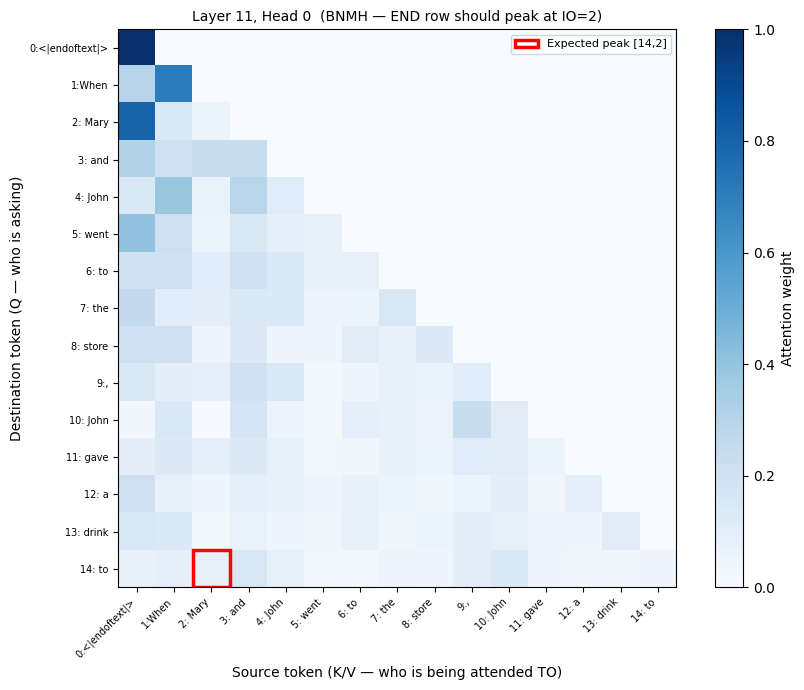


L10.H6 (NNMH) — attention at END (row 14):
  src= 0 '<|endoftext|>': 0.5541  ██████████████████████
  src= 1 'When      ': 0.0021  
  src= 2 ' Mary     ': 0.1080  ████ ← IO (Mary)
  src= 3 ' and      ': 0.0032  
  src= 4 ' John     ': 0.2012  ████████
  src= 5 ' went     ': 0.0012  
  src= 6 ' to       ': 0.0010  
  src= 7 ' the      ': 0.0006  
  src= 8 ' store    ': 0.0191  
  src= 9 ',         ': 0.0019  
  src=10 ' John     ': 0.0988  ███ ← S2 (John)
  src=11 ' gave     ': 0.0017  
  src=12 ' a        ': 0.0009  
  src=13 ' drink    ': 0.0039  
  src=14 ' to       ': 0.0022  
  Saved: ioi_outputs/nnmh_L10H6_attn.png


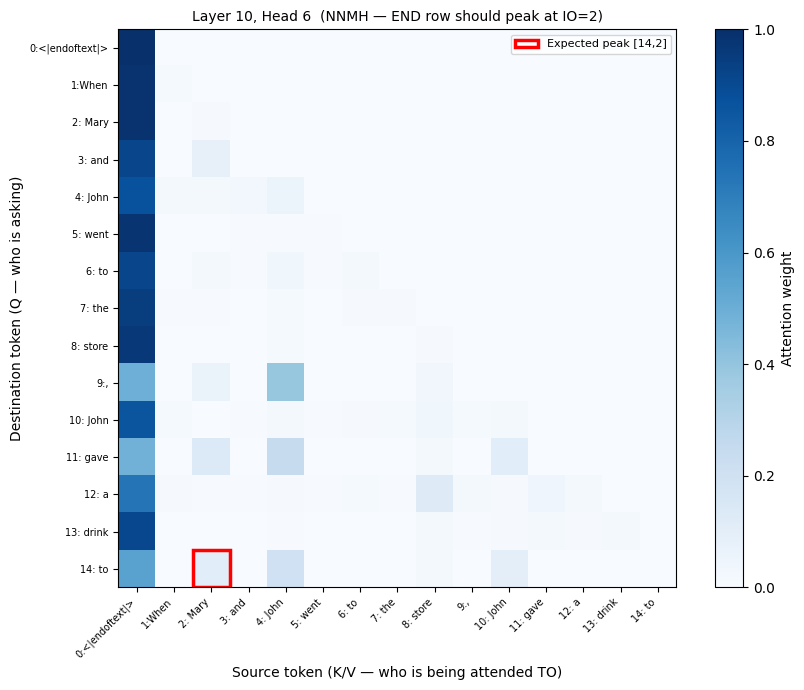


L10.H10 (NNMH) — attention at END (row 14):
  src= 0 '<|endoftext|>': 0.5905  ███████████████████████
  src= 1 'When      ': 0.0198  
  src= 2 ' Mary     ': 0.2149  ████████ ← IO (Mary)
  src= 3 ' and      ': 0.0365  █
  src= 4 ' John     ': 0.0750  ██
  src= 5 ' went     ': 0.0028  
  src= 6 ' to       ': 0.0032  
  src= 7 ' the      ': 0.0031  
  src= 8 ' store    ': 0.0012  
  src= 9 ',         ': 0.0062  
  src=10 ' John     ': 0.0184   ← S2 (John)
  src=11 ' gave     ': 0.0053  
  src=12 ' a        ': 0.0045  
  src=13 ' drink    ': 0.0029  
  src=14 ' to       ': 0.0158  
  Saved: ioi_outputs/nnmh_L10H10_attn.png


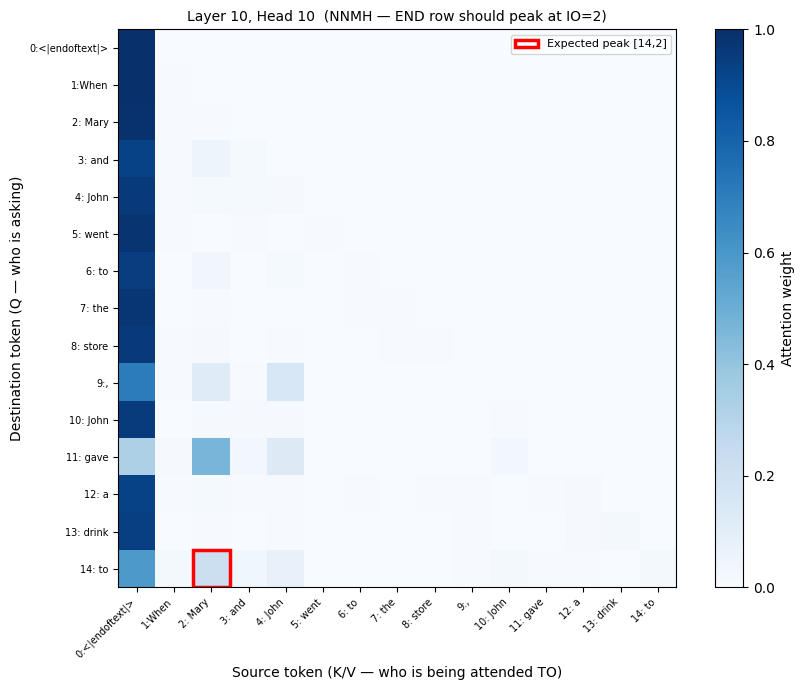

In [16]:
NMH_CANDIDATES  = [(9, 6),  (9, 9),  (10, 0)]
BNMH_CANDIDATES = [(10, 7), (11, 0)]
NNMH_CANDIDATES = [(10, 6), (10, 10)]
 
ALL_OUTPUT_HEADS = NMH_CANDIDATES + BNMH_CANDIDATES + NNMH_CANDIDATES
 
W_U      = model.W_U            # [d_model, vocab_size]
mary_dir = W_U[:, mary_token]   # [d_model] — "Mary direction" in logit space
john_dir = W_U[:, john_token]   # [d_model] — "John direction" in logit space
 
 
# ╔══════════════════════════════════════════════════════════════╗
# ║  EXPERIMENT A — Attention Patterns                          ║
# ║  All three head types (NMH, BNMH, NNMH) attend from END    ║
# ║  to IO (Mary). The DIFFERENCE is what they WRITE.           ║
# ╚══════════════════════════════════════════════════════════════╝
 
# ── A1. Rank all heads in layers 9–11 by attn[END, IO] ─────────
#
# All three head types share the same attention signature:
# they all look at Mary (IO_POS) from END.
# This is how we identify them — but attention alone can't
# tell NMH from NNMH. For that we need Experiment C (logit projection).
 
print("=" * 60)
print("EXPERIMENT A — Attention patterns: who attends to Mary?")
print("=" * 60)
print(f"\nRanking heads (layers 9–11) by attn[END={END_POS}, IO={IO_POS}]")
print("All of NMH, BNMH, NNMH should appear near the top.\n")
 
attn_to_io = {}
for layer in range(9, 12):
    pattern = cache_clean["pattern", layer]   # [1, n_heads, seq, seq]
    for head in range(model.cfg.n_heads):
        score = pattern[0, head, END_POS, IO_POS].item()
        attn_to_io[(layer, head)] = score
 
sorted_attn = sorted(attn_to_io.items(), key=lambda x: -x[1])
 
print(f"  {'Head':10s}  {'attn[END,IO]':>13s}  Type")
print(f"  {'-'*10}  {'-'*13}  {'-'*10}")
for (l, h), score in sorted_attn:
    tag = ""
    if (l, h) in NMH_CANDIDATES:  tag = "NMH  ◄"
    if (l, h) in BNMH_CANDIDATES: tag = "BNMH ◄"
    if (l, h) in NNMH_CANDIDATES: tag = "NNMH ◄"
    marker = f"  {tag}" if tag else ""
    print(f"  L{l:2d}.H{h:2d}     {score:>13.4f}{marker}")
 
 
# ── A2. Attention heatmaps for all 7 heads ──────────────────────
#
# Read the heatmaps like this:
#   - Look at row END_POS (bottom row, "to")
#   - A bright column at IO_POS (Mary) = this head copies Mary
#   - For NNMH, the pattern looks identical to NMH — the difference
#     is invisible in the attention map (you need Experiment C for that)
 
print("\nPlotting attention heatmaps for all output heads...")
 
type_labels = {}
for h in NMH_CANDIDATES:  type_labels[h] = "NMH"
for h in BNMH_CANDIDATES: type_labels[h] = "BNMH"
for h in NNMH_CANDIDATES: type_labels[h] = "NNMH"
 
for layer, head in ALL_OUTPUT_HEADS:
    pattern  = cache_clean["pattern", layer][0, head]  # [seq, seq]
    head_type = type_labels[(layer, head)]
 
    # Print END row as bar chart
    print(f"\nL{layer}.H{head} ({head_type}) — attention at END (row {END_POS}):")
    for src in range(len(token_strs)):
        bar = "█" * int(pattern[END_POS, src].item() * 40)
        tag = " ← IO (Mary)" if src == IO_POS else \
              " ← S2 (John)" if src == S2_POS else ""
        print(f"  src={src:2d} '{token_strs[src]:10s}': "
              f"{pattern[END_POS, src].item():.4f}  {bar}{tag}")
 
    plot_attention(
        pattern, layer, head, token_strs,
        highlight_dest=END_POS,
        highlight_src=IO_POS,
        title_suffix=f"({head_type} — END row should peak at IO={IO_POS})",
        save_path=f"ioi_outputs/{head_type.lower()}_L{layer}H{head}_attn.png"
    )